In [1]:
!pip install geopandas shapely fiona pyproj

In [2]:
!pip install geopandas contextily

In [3]:
!pip install geopandas contextily shapely

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point
from matplotlib.patches import Patch

In [6]:
df = pd.read_csv('/content/drive/MyDrive/dataset/Data rokok1.csv', delimiter=";")

In [7]:
df

,Kelurahan,SSB,KSN,SBS,Spc 16,SE12,SE16,BCK,LS 12,LS 16,TRN B,Spirit,RVL 16,LSFB 12,RVL M 12,Sale_Total,Toko_Didatangi,Toko_Membeli
0,jatiwaringin,264,779,263,0,0,0,398,212,85,319,4,40,2,24,23617150,651,227
1,jatimakmur,178,1605,93,0,0,0,491,261,284,689,17,104,5,37,35262300,556,279
2,bojong rawalumbu,119,765,60,0,0,0,825,280,206,324,0,19,0,25,23889200,535,245
3,sumurbatu,296,691,79,0,0,0,105,220,666,392,2,38,0,15,24618200,643,214
4,cikiwul,389,1060,192,0,0,0,850,358,670,985,1,70,6,51,43694200,1183,469
5,ciketingudik,669,1571,157,0,0,0,601,253,334,1667,3,96,0,39,51484950,1127,508
6,jatibening,426,1285,45,0,0,0,219,137,493,238,0,57,0,84,31368800,646,285
7,jatibening baru,271,627,41,0,0,0,270,364,756,590,2,62,0,23,28650650,694,284
8,jaticempaka,237,557,261,0,0,0,315,87,280,301,0,82,2,15,21057800,680,233
9,bantargebang,278,613,96,0,0,0,170,136,192,502,6,84,9,52,21660800,544,216


In [8]:
df.columns = df.columns.str.strip()
features = df.drop(['Kelurahan'], axis=1)

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

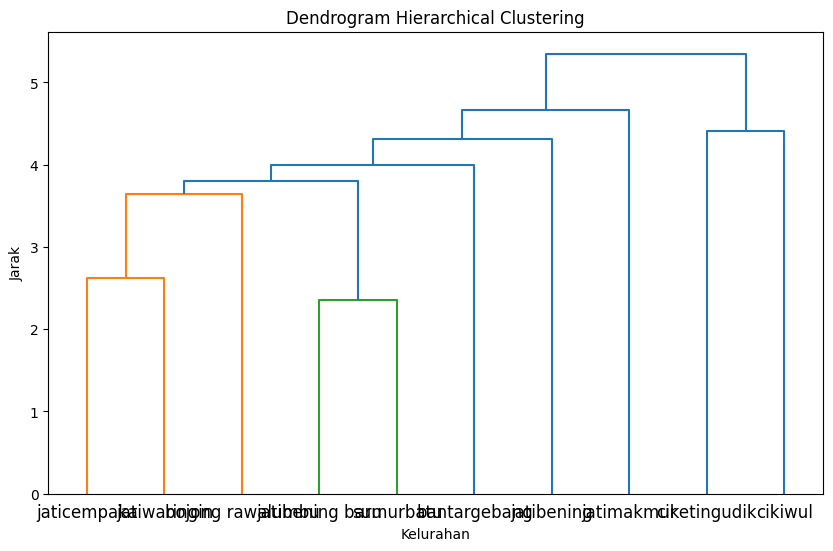

In [11]:
linked = linkage(X_scaled, method='single')

plt.figure(figsize=(10,6))
dendrogram(
    linked,
    labels=df["Kelurahan"].values,
    distance_sort='descending'
)
plt.title("Dendrogram Hierarchical Clustering")
plt.xlabel("Kelurahan")
plt.ylabel("Jarak")
plt.show()

In [12]:
hac = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='single'
)

df["Cluster"] = hac.fit_predict(X_scaled)
df


,Kelurahan,SSB,KSN,SBS,Spc 16,SE12,SE16,BCK,LS 12,LS 16,TRN B,Spirit,RVL 16,LSFB 12,RVL M 12,Sale_Total,Toko_Didatangi,Toko_Membeli,Cluster
0,jatiwaringin,264,779,263,0,0,0,398,212,85,319,4,40,2,24,23617150,651,227,2
1,jatimakmur,178,1605,93,0,0,0,491,261,284,689,17,104,5,37,35262300,556,279,1
2,bojong rawalumbu,119,765,60,0,0,0,825,280,206,324,0,19,0,25,23889200,535,245,2
3,sumurbatu,296,691,79,0,0,0,105,220,666,392,2,38,0,15,24618200,643,214,2
4,cikiwul,389,1060,192,0,0,0,850,358,670,985,1,70,6,51,43694200,1183,469,0
5,ciketingudik,669,1571,157,0,0,0,601,253,334,1667,3,96,0,39,51484950,1127,508,0
6,jatibening,426,1285,45,0,0,0,219,137,493,238,0,57,0,84,31368800,646,285,2
7,jatibening baru,271,627,41,0,0,0,270,364,756,590,2,62,0,23,28650650,694,284,2
8,jaticempaka,237,557,261,0,0,0,315,87,280,301,0,82,2,15,21057800,680,233,2
9,bantargebang,278,613,96,0,0,0,170,136,192,502,6,84,9,52,21660800,544,216,2


In [13]:
cluster_map = {
    0: "Potensi Tinggi",
    1: "Potensi Sedang",
    2: "Potensi Rendah"
}

df["Kategori_Potensi"] = df["Cluster"].map(cluster_map)
df


,Kelurahan,SSB,KSN,SBS,Spc 16,SE12,SE16,BCK,LS 12,LS 16,TRN B,Spirit,RVL 16,LSFB 12,RVL M 12,Sale_Total,Toko_Didatangi,Toko_Membeli,Cluster,Kategori_Potensi
0,jatiwaringin,264,779,263,0,0,0,398,212,85,319,4,40,2,24,23617150,651,227,2,Potensi Rendah
1,jatimakmur,178,1605,93,0,0,0,491,261,284,689,17,104,5,37,35262300,556,279,1,Potensi Sedang
2,bojong rawalumbu,119,765,60,0,0,0,825,280,206,324,0,19,0,25,23889200,535,245,2,Potensi Rendah
3,sumurbatu,296,691,79,0,0,0,105,220,666,392,2,38,0,15,24618200,643,214,2,Potensi Rendah
4,cikiwul,389,1060,192,0,0,0,850,358,670,985,1,70,6,51,43694200,1183,469,0,Potensi Tinggi
5,ciketingudik,669,1571,157,0,0,0,601,253,334,1667,3,96,0,39,51484950,1127,508,0,Potensi Tinggi
6,jatibening,426,1285,45,0,0,0,219,137,493,238,0,57,0,84,31368800,646,285,2,Potensi Rendah
7,jatibening baru,271,627,41,0,0,0,270,364,756,590,2,62,0,23,28650650,694,284,2,Potensi Rendah
8,jaticempaka,237,557,261,0,0,0,315,87,280,301,0,82,2,15,21057800,680,233,2,Potensi Rendah
9,bantargebang,278,613,96,0,0,0,170,136,192,502,6,84,9,52,21660800,544,216,2,Potensi Rendah


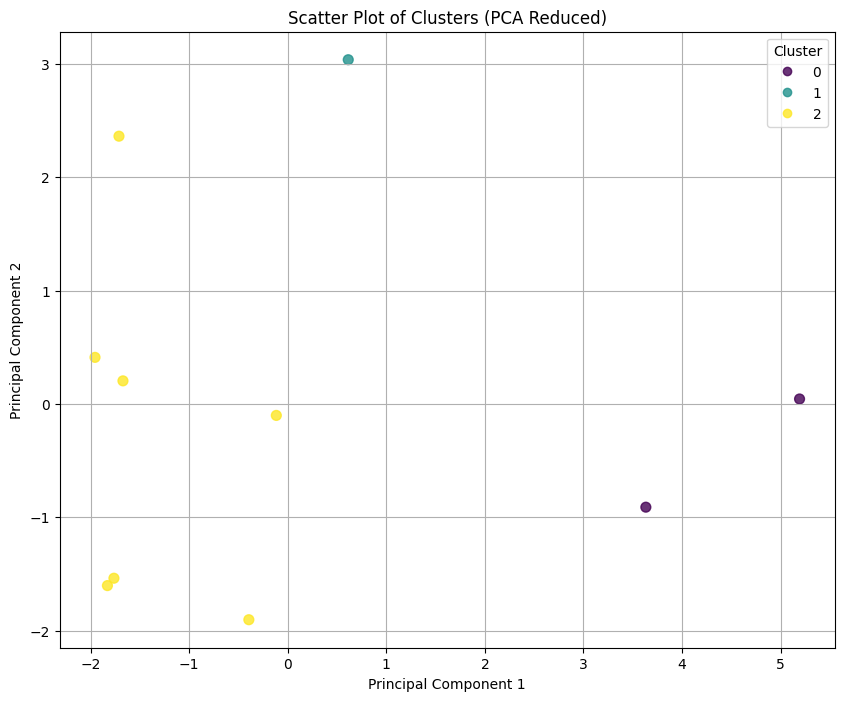

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = df['Cluster']

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_df['Principal Component 1'], pca_df['Principal Component 2'], c=pca_df['Cluster'], cmap='viridis', s=50, alpha=0.8)

plt.title('Scatter Plot of Clusters (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.grid(True)
plt.show()

In [15]:
kordinat = pd.read_csv('/content/drive/MyDrive/dataset/kordinat2.csv')
kordinat

,Kelurahan,Latitude,Longitude
0,jatiwaringin,-6.273960,106.916271
1,jatimakmur,-6.280795,106.928787
2,bojong rawalumbu,-6.284686,106.992340
3,sumurbatu,-6.347312,107.009634
4,cikiwul,-6.338539,106.985350
5,ciketingudik,-6.353430,106.987609
6,jatibening,-6.258157,106.951827
7,jatibening baru,-6.259707,106.934406
8,jaticempaka,-6.260916,106.915758
9,bantargebang,-6.321170,106.982094


In [16]:
# Standardize 'Kelurahan' column in kordinat for merging
kordinat['Kelurahan'] = kordinat['Kelurahan'].str.strip().str.lower()
df['Kelurahan'] = df['Kelurahan'].str.strip().str.lower() # Ensure df's Kelurahan is also stripped and lowercased for robust merge

# Rename 'Longitude;;' to 'Longitude' and clean its values
kordinat.rename(columns={'Longitude;;': 'Longitude'}, inplace=True)
kordinat['Longitude'] = kordinat['Longitude'].astype(str).str.replace(';', '').astype(float)

# The 'Latitude' column seems to be already parsed as float, so no need for .str.replace or further conversion

# Merge dataframes
df_merged = pd.merge(df, kordinat, on='Kelurahan', how='left')

# Create GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_merged,
    geometry=gpd.points_from_xy(df_merged["Longitude"], df_merged["Latitude"]),
    crs="EPSG:4326"
)

gdf

,Kelurahan,SSB,KSN,SBS,Spc 16,SE12,SE16,BCK,LS 12,LS 16,...,LSFB 12,RVL M 12,Sale_Total,Toko_Didatangi,Toko_Membeli,Cluster,Kategori_Potensi,Latitude,Longitude,geometry
0,jatiwaringin,264,779,263,0,0,0,398,212,85,...,2,24,23617150,651,227,2,Potensi Rendah,-6.273960,106.916271,POINT (106.91627 -6.27396)
1,jatimakmur,178,1605,93,0,0,0,491,261,284,...,5,37,35262300,556,279,1,Potensi Sedang,-6.280795,106.928787,POINT (106.92879 -6.28079)
2,bojong rawalumbu,119,765,60,0,0,0,825,280,206,...,0,25,23889200,535,245,2,Potensi Rendah,-6.284686,106.992340,POINT (106.99234 -6.28469)
3,sumurbatu,296,691,79,0,0,0,105,220,666,...,0,15,24618200,643,214,2,Potensi Rendah,-6.347312,107.009634,POINT (107.00963 -6.34731)
4,cikiwul,389,1060,192,0,0,0,850,358,670,...,6,51,43694200,1183,469,0,Potensi Tinggi,-6.338539,106.985350,POINT (106.98535 -6.33854)
5,ciketingudik,669,1571,157,0,0,0,601,253,334,...,0,39,51484950,1127,508,0,Potensi Tinggi,-6.353430,106.987609,POINT (106.98761 -6.35343)
6,jatibening,426,1285,45,0,0,0,219,137,493,...,0,84,31368800,646,285,2,Potensi Rendah,-6.258157,106.951827,POINT (106.95183 -6.25816)
7,jatibening baru,271,627,41,0,0,0,270,364,756,...,0,23,28650650,694,284,2,Potensi Rendah,-6.259707,106.934406,POINT (106.93441 -6.25971)
8,jaticempaka,237,557,261,0,0,0,315,87,280,...,2,15,21057800,680,233,2,Potensi Rendah,-6.260916,106.915758,POINT (106.91576 -6.26092)
9,bantargebang,278,613,96,0,0,0,170,136,192,...,9,52,21660800,544,216,2,Potensi Rendah,-6.321170,106.982094,POINT (106.98209 -6.32117)


In [17]:
gdf = gdf.to_crs(epsg=3857)

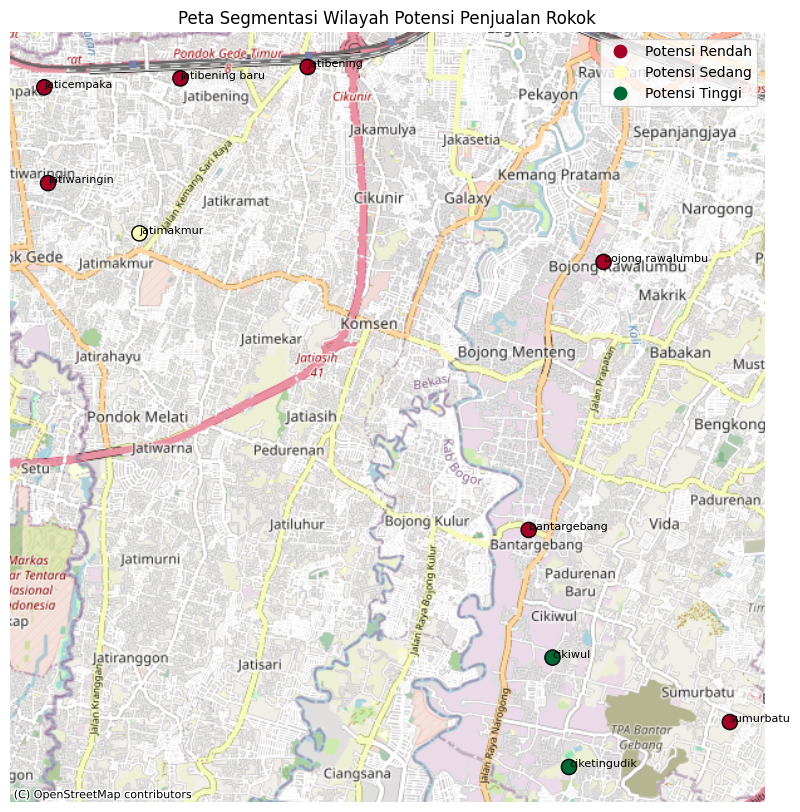

In [18]:
fig, ax = plt.subplots(figsize=(10,10))

gdf.plot(
    ax=ax,
    column="Kategori_Potensi",
    categorical=True,
    legend=True,
    cmap="RdYlGn",
    markersize=120,
    edgecolor="black"
)

# Tambahkan basemap OpenStreetMap
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik
)

# Label kelurahan
for x, y, label in zip(
    gdf.geometry.x,
    gdf.geometry.y,
    gdf["Kelurahan"]
):
    ax.text(x, y, label, fontsize=8)

ax.set_axis_off()
plt.title("Peta Segmentasi Wilayah Potensi Penjualan Rokok")
plt.show()


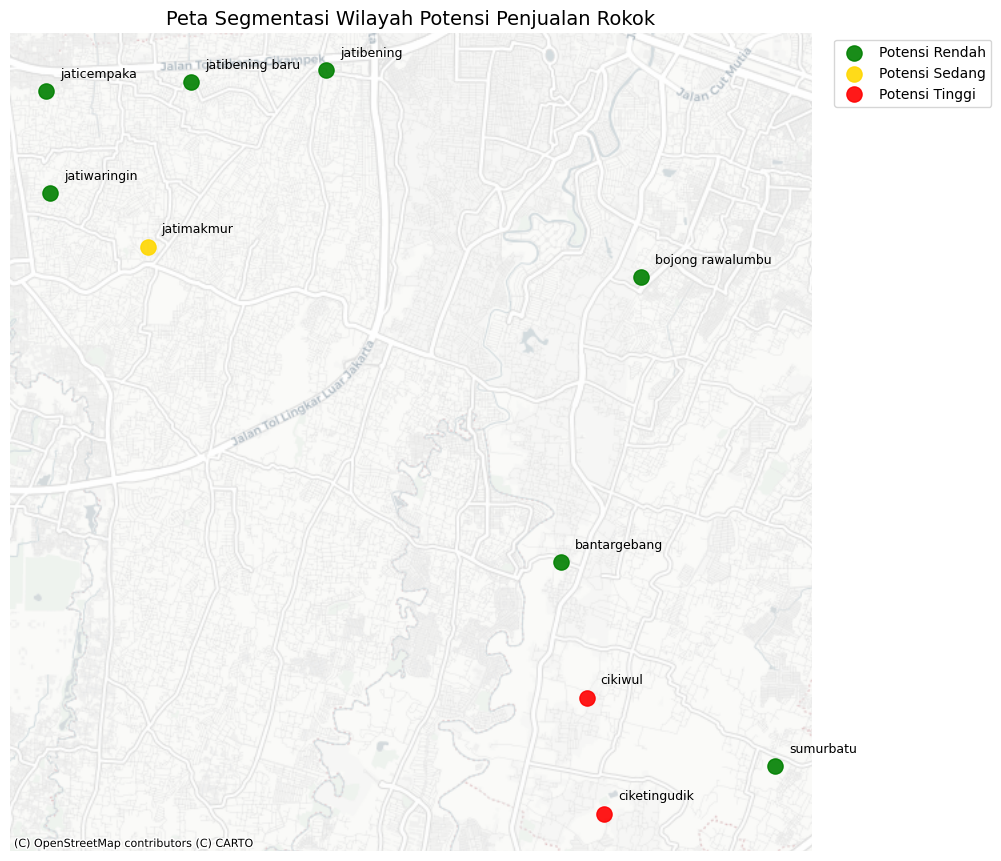

In [19]:
import matplotlib.pyplot as plt
import contextily as ctx

fig, ax = plt.subplots(figsize=(10, 10))

colors = {0:'red', 1:'gold', 2:'green'}
labels = {0:'Potensi Tinggi', 1:'Potensi Sedang', 2:'Potensi Rendah'}

for c in gdf['Cluster'].unique():
    subset = gdf[gdf['Cluster'] == c]
    subset.plot(
        ax=ax,
        color=colors[c],
        markersize=120,
        alpha=0.9,
        label=labels[c]
    )

# Tambah label kelurahan (offset supaya tidak nabrak)
for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf['Kelurahan']):
    ax.text(x+200, y+200, label, fontsize=9)

# Basemap bersih (abu-abu, tidak ramai)
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title("Peta Segmentasi Wilayah Potensi Penjualan Rokok", fontsize=14)
ax.set_axis_off()

# Legenda di luar peta
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

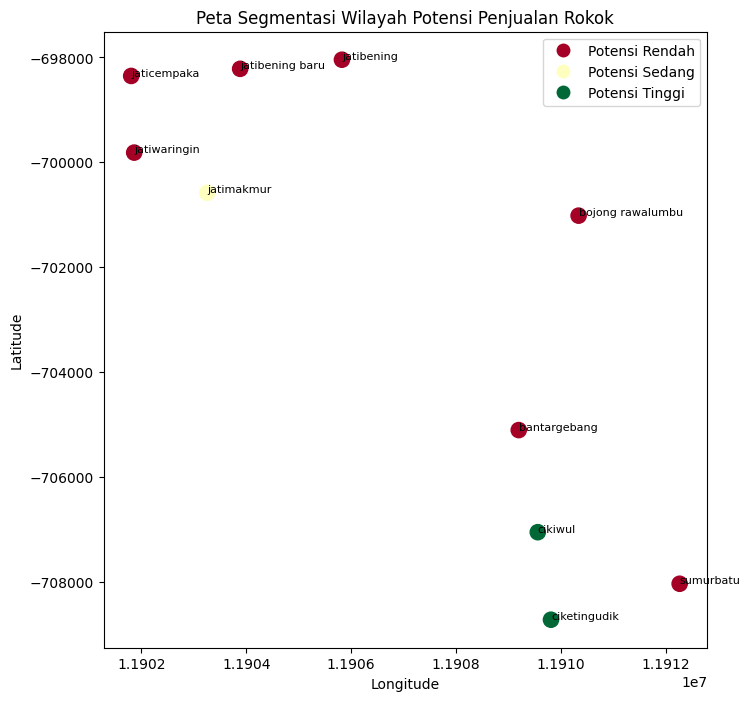

In [20]:
fig, ax = plt.subplots(figsize=(8,8))

gdf.plot(
    ax=ax,
    column="Kategori_Potensi",
    categorical=True,
    legend=True,
    cmap="RdYlGn",
    markersize=120
)

for x, y, label in zip(
    gdf.geometry.x,
    gdf.geometry.y,
    gdf["Kelurahan"]
):
    ax.text(x, y, label, fontsize=8)

plt.title("Peta Segmentasi Wilayah Potensi Penjualan Rokok")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


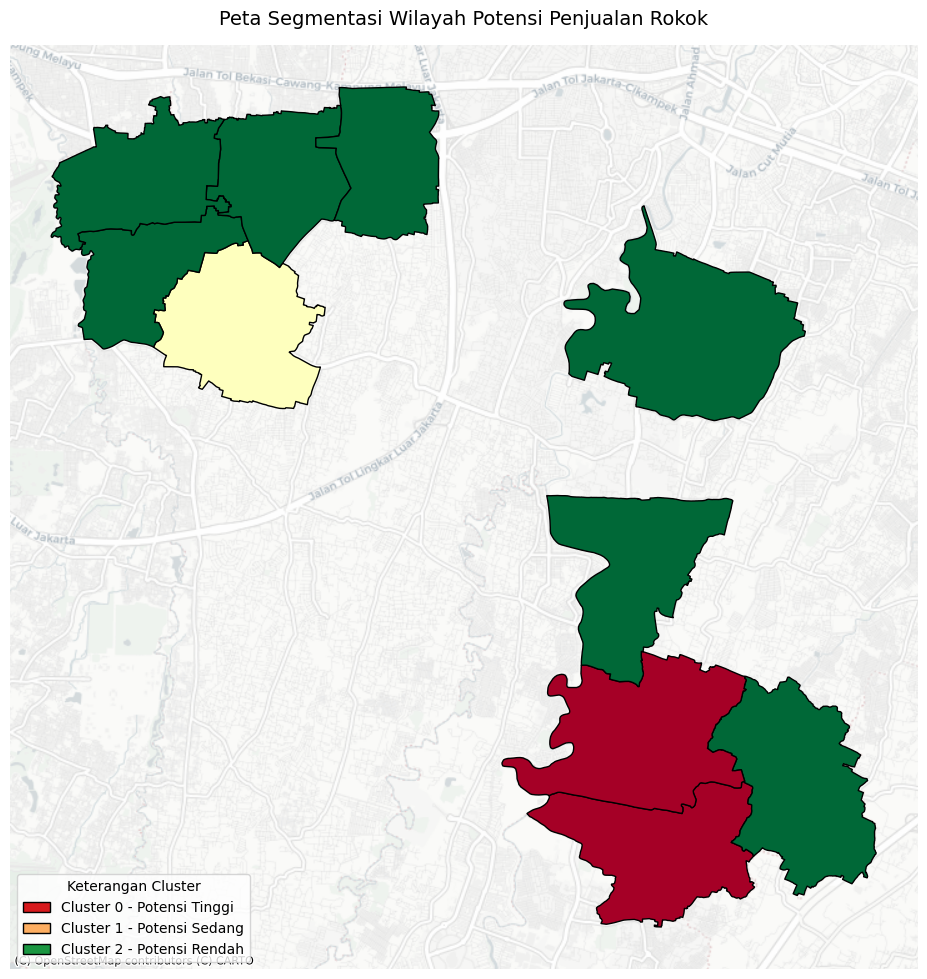

In [21]:
# Load shapefile kelurahan
gdf_map = gpd.read_file('/content/drive/MyDrive/dataset/kelurahan/ADMINISTRASI_AR_DESAKEL.shp')

# Standarisasi nama kelurahan
gdf_map['kelurahan'] = gdf_map['WADMKD'].str.strip().str.lower()
df['kelurahan'] = df['Kelurahan'].str.strip().str.lower()

# Merge data spasial dan clustering
gdf = gdf_map.merge(
    df,
    on='kelurahan',
    how='left'
)

# Reproject ke Web Mercator
gdf = gdf.to_crs(epsg=3857)

# =========================
# Mapping warna cluster
# =========================
cluster_colors = {
    0: '#d7191c',  # merah - potensi rendah
    1: '#fdae61',  # kuning - potensi sedang
    2: '#1a9641'   # hijau - potensi tinggi
}

# Map warna + fallback untuk NaN
gdf['color'] = gdf['Cluster'].map(cluster_colors)
gdf['color'] = gdf['color'].fillna('#d9d9d9')  # abu-abu

# The line below was redundant and overwrote the fillna, reintroducing NaNs
# gdf['color'] = gdf['Cluster'].map(cluster_colors)

# =========================
# Plot peta
# =========================
fig, ax = plt.subplots(figsize=(12,12))
gdf.plot(
    column='Cluster',
    cmap='RdYlGn',
    edgecolor='black',
    ax=ax
)

# Basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

# Judul
ax.set_title(
    'Peta Segmentasi Wilayah Potensi Penjualan Rokok',
    fontsize=14,
    pad=15
)

ax.axis('off')

# =========================
# Legend manual (jelas)
# =========================
legend_elements = [
    Patch(facecolor='#d7191c', edgecolor='black',
          label='Cluster 0 - Potensi Tinggi'),
    Patch(facecolor='#fdae61', edgecolor='black',
          label='Cluster 1 - Potensi Sedang'),
    Patch(facecolor='#1a9641', edgecolor='black',
          label='Cluster 2 - Potensi Rendah')
]

ax.legend(
    handles=legend_elements,
    loc='lower left',
    title='Keterangan Cluster'
)

plt.show()

In [22]:
df.columns = df.columns.str.strip()
df["Total_Penjualan"] = df[["SSB", "KSN", "SBS", "Spc 16", "SE12", "SE16", "BCK", "LS 12", "LS 16", "TRN B", "Spirit", "RVL 16", "LSFB 12", "RVL M 12"]].sum(axis=1)

df[[
    "Kelurahan",
    "Kelurahan",
    "Total_Penjualan",
    "Cluster",
    "Kategori_Potensi"
]]

,Kelurahan,Kelurahan,Total_Penjualan,Cluster,Kategori_Potensi
0,jatiwaringin,jatiwaringin,2390,2,Potensi Rendah
1,jatimakmur,jatimakmur,3764,1,Potensi Sedang
2,bojong rawalumbu,bojong rawalumbu,2623,2,Potensi Rendah
3,sumurbatu,sumurbatu,2504,2,Potensi Rendah
4,cikiwul,cikiwul,4632,0,Potensi Tinggi
5,ciketingudik,ciketingudik,5390,0,Potensi Tinggi
6,jatibening,jatibening,2984,2,Potensi Rendah
7,jatibening baru,jatibening baru,3006,2,Potensi Rendah
8,jaticempaka,jaticempaka,2137,2,Potensi Rendah
9,bantargebang,bantargebang,2138,2,Potensi Rendah


In [23]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score: {silhouette_avg:.2f}")

Silhouette Score: 0.21


In [24]:
sales_columns = ["SSB", "KSN", "SBS", "Spc 16", "SE12", "SE16", "BCK", "LS 12", "LS 16", "TRN B", "Spirit", "RVL 16", "LSFB 12", "RVL M 12"]

clustered_sales = df.groupby('Cluster')[sales_columns].sum()

def get_top_n_brands(data, n=3):
    top_brands = {}
    for cluster_id, row in data.iterrows():
        top_n = row.nlargest(n)
        top_brands[cluster_id] = top_n.index.tolist()
    return top_brands

top_3_brands_per_cluster = get_top_n_brands(clustered_sales, n=3)

print("Total sales per cluster for each brand:")
print(clustered_sales)
print("\nTop 3 brands per cluster:")
display(top_3_brands_per_cluster)

Total sales per cluster for each brand:
          SSB   KSN  SBS  Spc 16  SE12  SE16   BCK  LS 12  LS 16  TRN B  \
Cluster                                                                   
0        1058  2631  349       0     0     0  1451    611   1004   2652   
1         178  1605   93       0     0     0   491    261    284    689   
2        1891  5317  845       0     0     0  2302   1436   2678   2666   

         Spirit  RVL 16  LSFB 12  RVL M 12  
Cluster                                     
0             4     166        6        90  
1            17     104        5        37  
2            14     382       13       238  

Top 3 brands per cluster:


{0: ['TRN B', 'KSN', 'BCK'],
 1: ['KSN', 'TRN B', 'BCK'],
 2: ['KSN', 'LS 16', 'TRN B']}

In [25]:
def get_top_n_brands_per_kelurahan(row, sales_cols, n=3):
    # Ensure sales columns are numeric before applying nlargest
    kelurahan_sales = row[sales_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    # Sort brands by sales in descending order and get the top N brand names
    top_n = kelurahan_sales.nlargest(n)
    return top_n.index.tolist()

# Apply the function to each row of the original DataFrame to get top brands per kelurahan
df['Top_3_Dominant_Brands_Kelurahan'] = df.apply(
    lambda row: get_top_n_brands_per_kelurahan(row, sales_columns, n=3),
    axis=1
)

# Display the relevant columns for verification
kelurahan_brand_dominance = df[['Kelurahan', 'Cluster', 'Kategori_Potensi', 'Top_3_Dominant_Brands_Kelurahan']]
display(kelurahan_brand_dominance)

,Kelurahan,Cluster,Kategori_Potensi,Top_3_Dominant_Brands_Kelurahan
0,jatiwaringin,2,Potensi Rendah,"[KSN, BCK, TRN B]"
1,jatimakmur,1,Potensi Sedang,"[KSN, TRN B, BCK]"
2,bojong rawalumbu,2,Potensi Rendah,"[BCK, KSN, TRN B]"
3,sumurbatu,2,Potensi Rendah,"[KSN, LS 16, TRN B]"
4,cikiwul,0,Potensi Tinggi,"[KSN, TRN B, BCK]"
5,ciketingudik,0,Potensi Tinggi,"[TRN B, KSN, SSB]"
6,jatibening,2,Potensi Rendah,"[KSN, LS 16, SSB]"
7,jatibening baru,2,Potensi Rendah,"[LS 16, KSN, TRN B]"
8,jaticempaka,2,Potensi Rendah,"[KSN, BCK, TRN B]"
9,bantargebang,2,Potensi Rendah,"[KSN, TRN B, SSB]"


In [26]:
df[[
    "Kelurahan",
    "Cluster",
    "Kategori_Potensi",
    "Total_Penjualan",
    "Toko_Didatangi",
    "Toko_Membeli",
    "Top_3_Dominant_Brands_Kelurahan"
]]

,Kelurahan,Cluster,Kategori_Potensi,Total_Penjualan,Toko_Didatangi,Toko_Membeli,Top_3_Dominant_Brands_Kelurahan
0,jatiwaringin,2,Potensi Rendah,2390,651,227,"[KSN, BCK, TRN B]"
1,jatimakmur,1,Potensi Sedang,3764,556,279,"[KSN, TRN B, BCK]"
2,bojong rawalumbu,2,Potensi Rendah,2623,535,245,"[BCK, KSN, TRN B]"
3,sumurbatu,2,Potensi Rendah,2504,643,214,"[KSN, LS 16, TRN B]"
4,cikiwul,0,Potensi Tinggi,4632,1183,469,"[KSN, TRN B, BCK]"
5,ciketingudik,0,Potensi Tinggi,5390,1127,508,"[TRN B, KSN, SSB]"
6,jatibening,2,Potensi Rendah,2984,646,285,"[KSN, LS 16, SSB]"
7,jatibening baru,2,Potensi Rendah,3006,694,284,"[LS 16, KSN, TRN B]"
8,jaticempaka,2,Potensi Rendah,2137,680,233,"[KSN, BCK, TRN B]"
9,bantargebang,2,Potensi Rendah,2138,544,216,"[KSN, TRN B, SSB]"
